In [ ]:
# Example of downloading datasets with kagglehub

import os
import kagglehub

# Set the custom directory
os.environ['KAGGLEHUB_CACHE'] = ''

# Download latest version
path = kagglehub.dataset_download("ahsanneural/global-food-and-nutrition-database-2026")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████| 4.24M/4.24M [00:01<00:00, 2.96MB/s]

Extracting files...


Path to dataset files: datasets/ahsanneural/global-food-and-nutrition-database-2026/versions/1


In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, EfficientNetB2, EfficientNetB7, InceptionV3, EfficientNetV2B3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [27]:
# Check if GPU detected?
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for i, gpu in enumerate(gpus):
        # Get Specifications Details
        details = tf.config.experimental.get_device_details(gpu)
        gpu_name = details.get('device_name', 'Unknown GPU')
        compute_cap = details.get('compute_capability', 'Unknown')
        
        print(f"\n--- GPU #{i} ---")
        print(f"Name       : {gpu_name}")
        print(f"ID Path    : {gpu.name}")
        print(f"Compute Cap: {compute_cap}")
        
    # Built and Additional information
    print("\n--- Additional Information ---")
    print(f"TensorFlow Version          : {tf.__version__}")
    print(f"Built with CUDA             : {tf.test.is_built_with_cuda()}")
    print(f"Compute Capabilities Build  : {tf.sysconfig.get_build_info()['cuda_compute_capabilities']}")
else:
    print("❌ GPU Not Detected!")


--- GPU #0 ---
Name       : NVIDIA GeForce RTX 5060
ID Path    : /physical_device:GPU:0
Compute Cap: (12, 0)

--- Additional Information ---
TensorFlow Version          : 2.20.0-dev0+selfbuilt
Built with CUDA             : True
Compute Capabilities Build  : ['compute_120', 'compute_89', 'compute_86', 'compute_75', 'compute_61']


In [28]:
ROOT_DIR = "datasets/autism-spectrum"
EPOCHS = 15
BATCH_SIZE = 32
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)

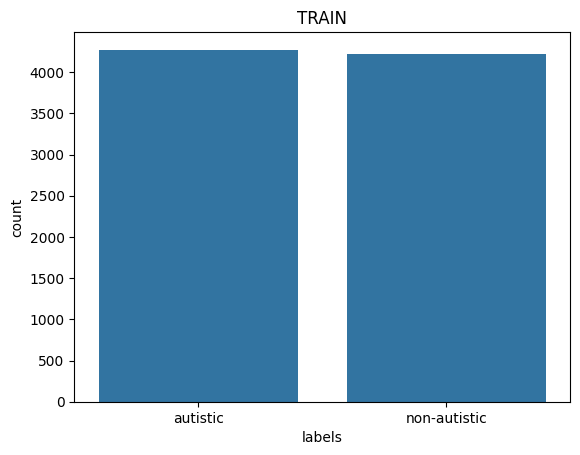

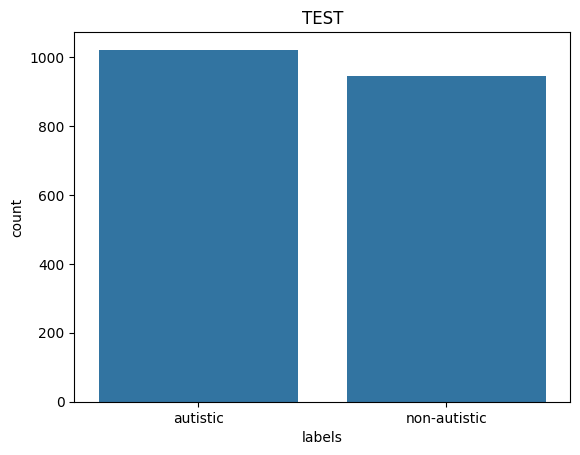

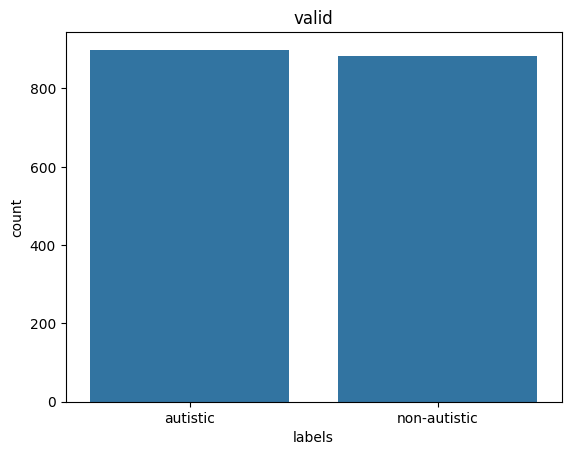

In [29]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_train_jpy.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_test_jpy.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_valid_jpy.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
sns.countplot(x='labels',data=valid_df)
plt.title('valid')
plt.show()

In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
)
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 8496 validated image filenames belonging to 2 classes.


In [39]:
test_datagen = ImageDataGenerator(rescale=1./255,)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=False
)

Found 1966 validated image filenames belonging to 2 classes.


In [32]:
valid_datagen = ImageDataGenerator(rescale=1./255,)
valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 1782 validated image filenames belonging to 2 classes.


In [33]:
# --- BUILD DUAL-BACKBONE MODEL (FIXED) ---
num_classes = len(train_gen.class_indices)
# 1 single input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2 backbones: instantiate WITHOUT input_shape so they don't create their own Input layers
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet")

# Freeze both initially
mobilenet_backbone.trainable = False
resnet_backbone.trainable = False

# Call both backbones on the SAME input tensor
m_feat = mobilenet_backbone(inputs)      # feature map from MobileNet
r_feat = resnet_backbone(inputs)         # feature map from ResNet

# Pool and combine
m_pool = GlobalAveragePooling2D()(m_feat)
r_pool = GlobalAveragePooling2D()(r_feat)

combined = Concatenate()([m_pool, r_pool])
combined = Dense(512, activation="relu")(combined)
combined = Dropout(0.5)(combined)

outputs = Dense(1, activation="sigmoid")(combined)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

/tmp/ipykernel_3987/848079698.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_6[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ input_layer_6[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │  1,704,448 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        513 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,527,745 (105.01 MB)

 Trainable params: 1,704,961 (6.50 MB)

 Non-trainable params: 25,822,784 (98.51 MB)

In [34]:
# === CALLBACKS ===
checkpoint = ModelCheckpoint("asr_backbone.keras", monitor="accuracy", save_best_only=True)
earlystop = EarlyStopping(monitor="accuracy", patience=6, restore_best_weights=True)

In [35]:
# === TRAIN ===
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/15


2026-02-12 20:42:04.265820: I external/local_xla/xla/service/service.cc:153] XLA service 0x7fbb440028f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-12 20:42:04.265865: I external/local_xla/xla/service/service.cc:161]   StreamExecutor device (0): NVIDIA GeForce RTX 5060, Compute Capability 12.0
2026-02-12 20:42:04.408293: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770903725.437882    4078 cuda_dnn.cc:529] Loaded cuDNN version 91701
2026-02-12 20:42:06.426467: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9128', 436 bytes spill stores, 436 bytes spill loads

2026-02-12 20:42:10.468197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optima

265/266 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7193 - loss: 0.6931

2026-02-12 20:43:24.129023: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2655', 436 bytes spill stores, 436 bytes spill loads



266/266 ━━━━━━━━━━━━━━━━━━━━ 93s 287ms/step - accuracy: 0.7690 - loss: 0.5192 - val_accuracy: 0.8221 - val_loss: 0.4002
Epoch 2/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.8302 - loss: 0.3727 - val_accuracy: 0.8356 - val_loss: 0.3686
Epoch 3/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8598 - loss: 0.3113 - val_accuracy: 0.8782 - val_loss: 0.2860
Epoch 4/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8844 - loss: 0.2665 - val_accuracy: 0.9046 - val_loss: 0.2437
Epoch 5/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9105 - loss: 0.2204 - val_accuracy: 0.8816 - val_loss: 0.2648
Epoch 6/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9326 - loss: 0.1731 - val_accuracy: 0.9343 - val_loss: 0.1885
Epoch 7/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9433 - loss: 0.1447 - val_accuracy: 0.9489 - val_loss: 0.1559
Epoch 8/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9543 - loss: 0.1226 - val_accura

In [36]:
# === EVALUATION ===
loss, acc = model.evaluate(test_gen)
print(f"\n🔥 Model Accuracy: {acc * 100:.2f}%")
print(f"📉 Model Loss: {loss:.4f}")

62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9654 - loss: 0.1336

🔥 Model Accuracy: 96.54%
📉 Model Loss: 0.1336


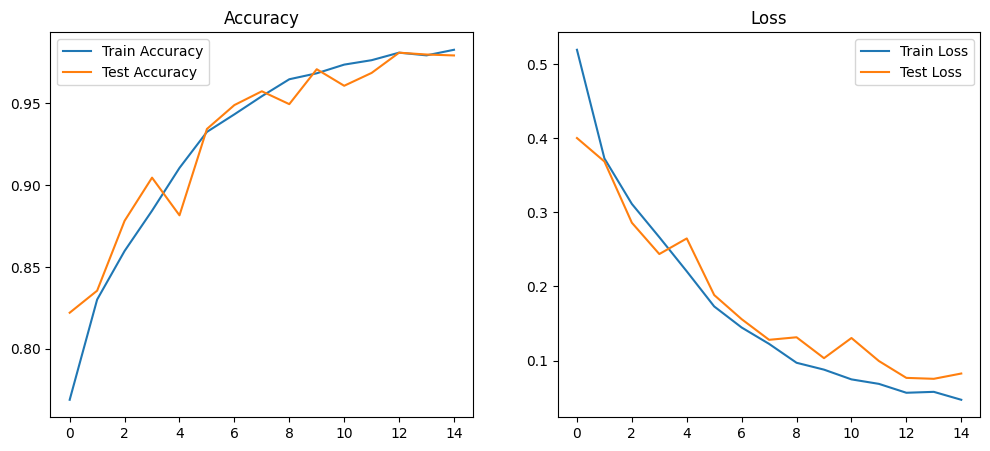

In [37]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("Loss")
plt.legend()

plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
              precision    recall  f1-score   support

    autistic       0.95      0.99      0.97      1021
non-autistic       0.98      0.94      0.96       945

    accuracy                           0.97      1966
   macro avg       0.97      0.96      0.97      1966
weighted avg       0.97      0.97      0.97      1966



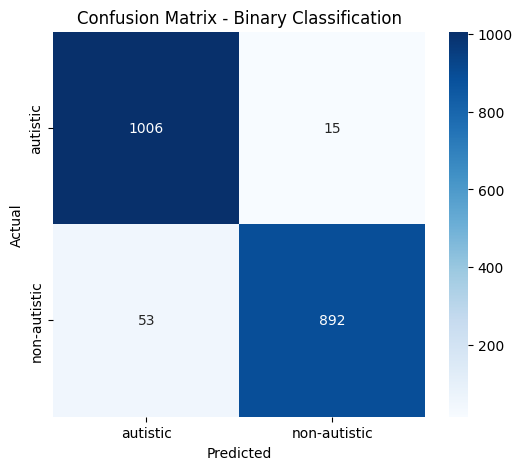

In [41]:
# 1. Ambil prediksi dalam bentuk probabilitas (0.0 sampai 1.0)
y_pred = model.predict(test_gen)

# 2. Ubah probabilitas jadi 0 atau 1 pake threshold 0.5
# Jangan pake argmax buat binary (1 output node)!
y_pred_class = (y_pred > 0.5).astype("int32").flatten()

# 3. Ambil label asli (ground truth)
y_true = test_gen.classes  
class_labels = list(test_gen.class_indices.keys())

# Sekarang print report-nya, pasti lebih masuk akal
print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_true, y_pred_class)

# Visualisasi tetep sama, tapi isinya udah bener
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()